In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import sys

In [4]:
PROJECT_ROOT = Path.cwd().parent.parent

sys.path.append(str(PROJECT_ROOT))

from ml.preprocessing.load_data import load_dataset

In [5]:
orders_df = load_dataset("olist_orders_dataset.csv")

In [6]:
orders_df.shape

(99441, 8)

In [7]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
orders_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [9]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [10]:
orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [11]:
orders_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [12]:
orders_df.duplicated().sum()

np.int64(0)

In [13]:
orders_df["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [14]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

orders_df[date_columns] = orders_df[date_columns].apply(pd.to_datetime)

orders_df.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [15]:
print("First Order :", orders_df["order_purchase_timestamp"].min())
print("Last Order  :", orders_df["order_purchase_timestamp"].max())

First Order : 2016-09-04 21:15:19
Last Order  : 2018-10-17 17:30:18


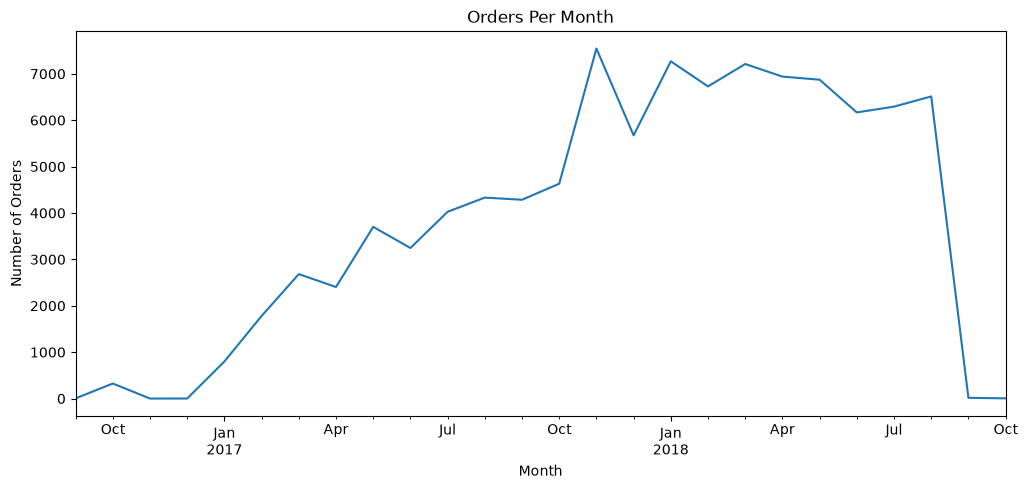

In [16]:
monthly_orders = (
    orders_df
    .set_index("order_purchase_timestamp")
    .resample("ME")
    .size()
)

monthly_orders.plot(figsize=(12, 5))

plt.title("Orders Per Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.show()

In [1]:
import sys
print(sys.executable)

d:\forecast-engine\.venv\Scripts\python.exe


In [2]:
import seaborn as sns
print(sns.__version__)

0.13.2


In [17]:
customers_df = load_dataset("olist_customers_dataset.csv")
products_df = load_dataset("olist_products_dataset.csv")
order_items_df = load_dataset("olist_order_items_dataset.csv")
payments_df = load_dataset("olist_order_payments_dataset.csv")
reviews_df = load_dataset("olist_order_reviews_dataset.csv")

In [18]:
datasets = {
    "Orders": orders_df,
    "Customers": customers_df,
    "Products": products_df,
    "Order Items": order_items_df,
    "Payments": payments_df,
    "Reviews": reviews_df,
}

for name, df in datasets.items():
    print(f"{name:<15} : {df.shape}")

Orders          : (99441, 8)
Customers       : (99441, 5)
Products        : (32951, 9)
Order Items     : (112650, 7)
Payments        : (103886, 5)
Reviews         : (99224, 7)


In [19]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isnull().sum())


Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Products
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Order Items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_v

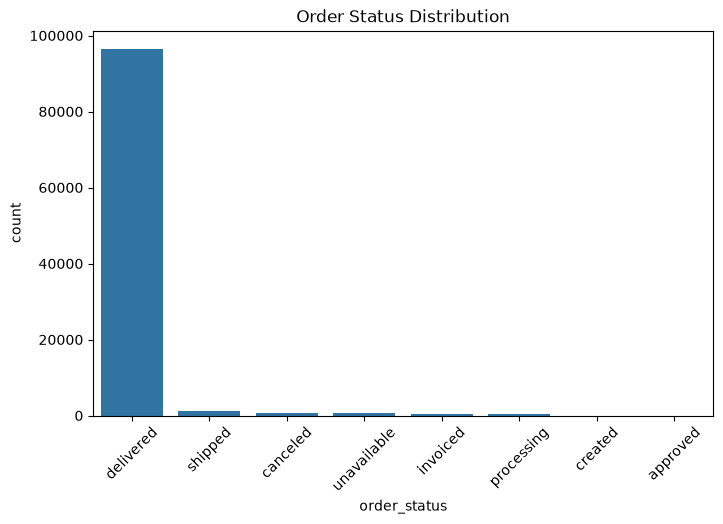

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=orders_df,
    x="order_status",
    order=orders_df["order_status"].value_counts().index,
)

plt.title("Order Status Distribution")
plt.xticks(rotation=45)

plt.show()

# Initial Observations

- Orders dataset contains 99,441 records.
- Date columns need datetime conversion.
- Some columns contain missing values.
- No duplicate rows were found.
- Most orders are in the "delivered" status.
- Multiple datasets are connected through common keys such as order_id, customer_id, and product_id.